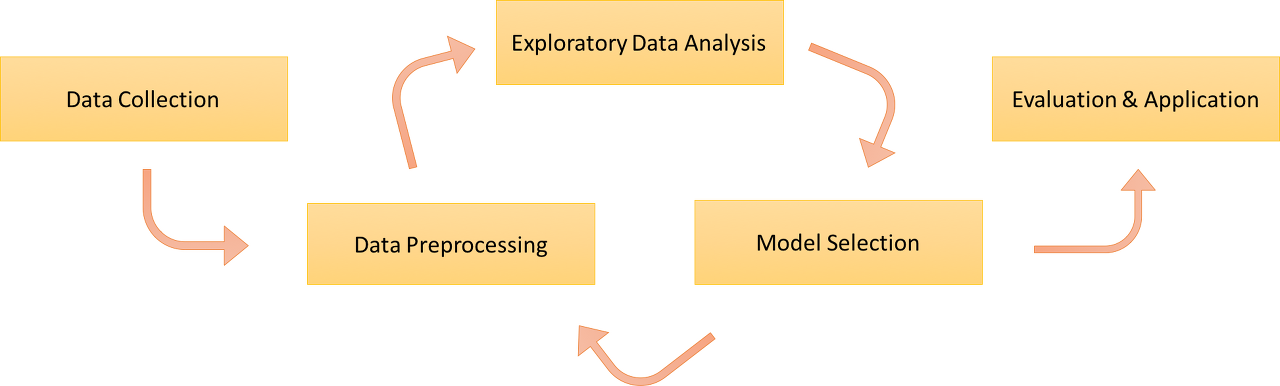

## <span style="color:red;font-weight:bold">데이터 전처리(Data Preprocessing)</span>
- 수집한 데이터를 파악하고 머신러닝 입력에 적합한 형태로 변환하는 단계가 데이터 전처리이다.
- 필요없는 피쳐(속성)를 제거하거나 새로운 피쳐(속성)를 추가한다.
- 중복데이터를 확인하고 있으면 제거한다.
- 결측치를 파악하고 처리한다.
- 이상치를 파악하고 처리한다.
- 수치 데이터의 스케일링을 처리한다.(머신러닝이나 딥러닝 모델의 처리 성능을 높이기 위해 스케일링을 진행한다.) 
- 범주형 데이터의 더미화를 처리한다.(머신러닝이나 딥러닝에서는 수치형 데이터만 처리 가능하므로 범주형 데이터를 적당한 수치로 변환한다.) 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns #seaborn 그래프 그려주는 라이브러리

## **데이터 전처리(1)**
### 데이터의 결측치 채크와 처리

In [2]:
dict = {'First Score':[100, 90, None, 95, 85, 70, None], #None = np.nan
        'Second Score': [30, 45, None, np.nan, 60, 90, 70], 
        'Third Score':[np.nan, 40, np.nan, 80, np.nan, 60, 100]} 
df = pd.DataFrame(dict) 
display(df)

,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
2,NaN,NaN,NaN
3,95.0,NaN,80.0
4,85.0,60.0,NaN
5,70.0,90.0,60.0
6,NaN,70.0,100.0


In [3]:
df.isna() # NaN, none값 확인하는 명령어

,First Score,Second Score,Third Score
0,False,False,True
1,False,False,False
2,True,True,True
3,False,True,False
4,False,False,True
5,False,False,False
6,True,False,False


In [4]:
df.isna().sum()

First Score     2
Second Score    2
Third Score     3
dtype: int64

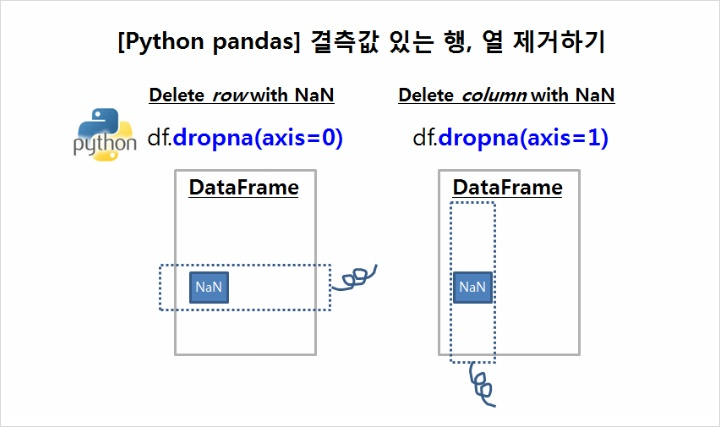

In [5]:
df.dropna(axis=0, how="all") #axis=0 행 / how="all" 모든 데이터가 결측치인 애는 날리겠어

,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
3,95.0,NaN,80.0
4,85.0,60.0,NaN
5,70.0,90.0,60.0
6,NaN,70.0,100.0


In [6]:
df.dropna(axis=0) #axis=0 행 how에 기본값은 any이므로, 하나라도 있으면 날림

,First Score,Second Score,Third Score
1,90.0,45.0,40.0
5,70.0,90.0,60.0


In [7]:
df

,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
2,NaN,NaN,NaN
3,95.0,NaN,80.0
4,85.0,60.0,NaN
5,70.0,90.0,60.0
6,NaN,70.0,100.0


In [8]:
df.dropna(axis=1) #axis=1 열

""
0
1
2
3
4
5
6


In [9]:
df.dropna(axis=1, thresh=5) # 결측치(none)가 아닌 데이터가 5개 보다 적으면 해당 열을 삭제하겠다.

,First Score,Second Score
0,100.0,30.0
1,90.0,45.0
2,NaN,NaN
3,95.0,NaN
4,85.0,60.0
5,70.0,90.0
6,NaN,70.0


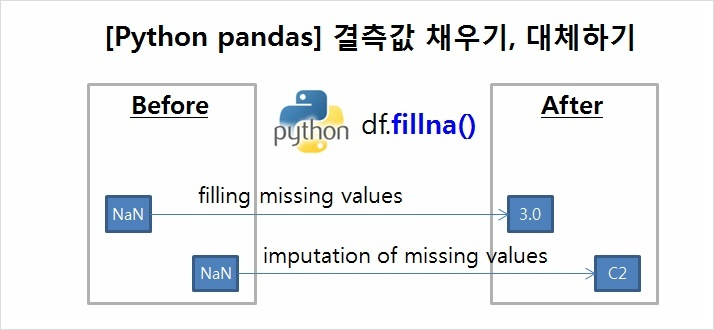

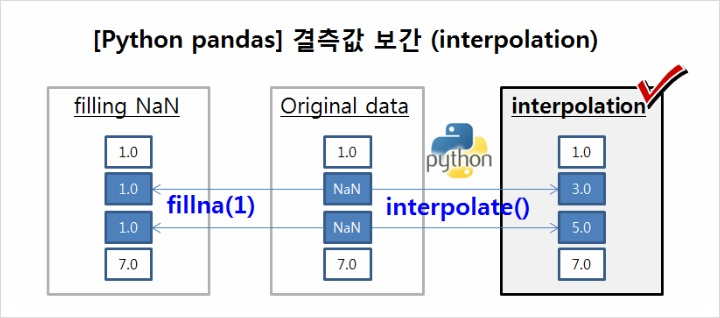

In [10]:
df.fillna(0)

,First Score,Second Score,Third Score
0,100.0,30.0,0.0
1,90.0,45.0,40.0
2,0.0,0.0,0.0
3,95.0,0.0,80.0
4,85.0,60.0,0.0
5,70.0,90.0,60.0
6,0.0,70.0,100.0


In [11]:
df.mean(axis=0) 

First Score     88.0
Second Score    59.0
Third Score     70.0
dtype: float64

In [12]:
df.fillna(df.mean(axis=0)) # 채우고 싶은 값을 () 평균값으로 채워짐

,First Score,Second Score,Third Score
0,100.0,30.0,70.0
1,90.0,45.0,40.0
2,88.0,59.0,70.0
3,95.0,59.0,80.0
4,85.0,60.0,70.0
5,70.0,90.0,60.0
6,88.0,70.0,100.0


In [13]:
df.ffill() #앞에 값으로

,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
2,90.0,45.0,40.0
3,95.0,45.0,80.0
4,85.0,60.0,80.0
5,70.0,90.0,60.0
6,70.0,70.0,100.0


In [14]:
df.bfill()  #뒤에 값으로 

,First Score,Second Score,Third Score
0,100.0,30.0,40.0
1,90.0,45.0,40.0
2,95.0,60.0,80.0
3,95.0,60.0,80.0
4,85.0,60.0,60.0
5,70.0,90.0,60.0
6,NaN,70.0,100.0


### 선형 보간법(linear interpolation) : 끝점의 값이 주어졌을 때 그 사이에 위치한 값을 추정하기 위하여 직선 거리에 따라 선형적으로 계산하는 방법

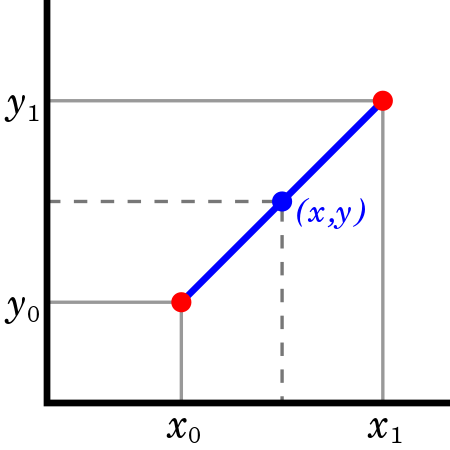

In [15]:
df

,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
2,NaN,NaN,NaN
3,95.0,NaN,80.0
4,85.0,60.0,NaN
5,70.0,90.0,60.0
6,NaN,70.0,100.0


In [16]:
df.interpolate(limit_direction ='forward') 

,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
2,92.5,50.0,60.0
3,95.0,55.0,80.0
4,85.0,60.0,70.0
5,70.0,90.0,60.0
6,70.0,70.0,100.0


In [17]:
df.interpolate(limit_direction ='backward') 

,First Score,Second Score,Third Score
0,100.0,30.0,40.0
1,90.0,45.0,40.0
2,92.5,50.0,60.0
3,95.0,55.0,80.0
4,85.0,60.0,70.0
5,70.0,90.0,60.0
6,NaN,70.0,100.0


In [18]:
df.interpolate(limit_direction ='both') #forward했다가 backward

,First Score,Second Score,Third Score
0,100.0,30.0,40.0
1,90.0,45.0,40.0
2,92.5,50.0,60.0
3,95.0,55.0,80.0
4,85.0,60.0,70.0
5,70.0,90.0,60.0
6,70.0,70.0,100.0


In [19]:
import seaborn as sns

# titanic 데이터셋 가져오기
titanic = sns.load_dataset('titanic')
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


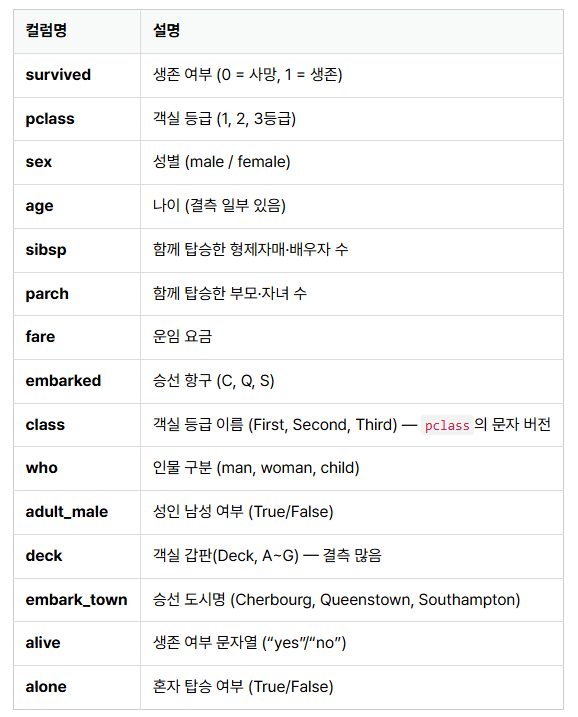

In [21]:
print(titanic.head().isnull())

   survived  pclass    sex    age  sibsp  parch   fare  embarked  class  \
0     False   False  False  False  False  False  False     False  False   
1     False   False  False  False  False  False  False     False  False   
2     False   False  False  False  False  False  False     False  False   
3     False   False  False  False  False  False  False     False  False   
4     False   False  False  False  False  False  False     False  False   

     who  adult_male   deck  embark_town  alive  alone  
0  False       False   True        False  False  False  
1  False       False  False        False  False  False  
2  False       False   True        False  False  False  
3  False       False  False        False  False  False  
4  False       False   True        False  False  False  


In [22]:
# 결측치 요약
print(titanic.isnull().sum())
#null값 합

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [23]:
# 생존률 평균
print(titanic['survived'].mean()) #40프로 생존

0.3838383838383838


In [24]:
# 성별별 생존률 비교
print(titanic.groupby('sex')['survived'].mean()) #생존률안에서 여자는 70프로 남자는 20프로 

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


<Axes: xlabel='sex'>

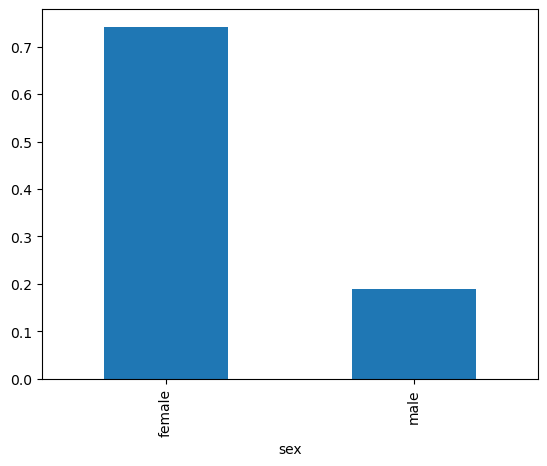

In [25]:
titanic.groupby('sex')['survived'].mean().plot(kind="bar")

In [26]:
df_age = titanic.dropna(subset=['age'], how='any', axis=0) #how='all'
print(len(df_age))

714


In [27]:
df_age.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False


In [28]:
# age 열의 NaN값을 다른 나이 데이터의 평균으로 변경하기
mean_age = titanic['age'].mean()   # age 열의 평균 계산 (NaN 값 제외)
mean_age

np.float64(29.69911764705882)

In [29]:
titanic['age'].fillna(mean_age, inplace=True)
df.head(10)

C:\Users\user\AppData\Local\Temp\ipykernel_21768\3799009438.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(mean_age, inplace=True)


,First Score,Second Score,Third Score
0,100.0,30.0,NaN
1,90.0,45.0,40.0
2,NaN,NaN,NaN
3,95.0,NaN,80.0
4,85.0,60.0,NaN
5,70.0,90.0,60.0
6,NaN,70.0,100.0


In [30]:
# embark_town 열의 829행의 NaN 데이터 출력
titanic['embark_town'][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: object

In [31]:
titanic['embark_town'].value_counts(dropna=True)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [32]:
# embark_town 열의 NaN값을 승선도시 중에서 가장 많이 출현한 값으로 치환하기
most_freq = titanic['embark_town'].value_counts(dropna=True).idxmax()   
print(most_freq)

Southampton


In [33]:
titanic['embark_town'].fillna(most_freq, inplace=True)

# embark_town 열 829행의 NaN 데이터 출력 (NaN 값이 most_freq 값으로 대체)
titanic['embark_town'][825:830] #829 NaN이였는데, Southampton으로 값이 바뀜

C:\Users\user\AppData\Local\Temp\ipykernel_21768\164812394.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['embark_town'].fillna(most_freq, inplace=True)


825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829    Southampton
Name: embark_town, dtype: object

In [34]:
# 예제 5-5
# 라이브러리 불러오기
import seaborn as sns

# titanic 데이터셋 가져오기
df = sns.load_dataset('titanic')

# embark_town 열의 829행의 NaN 데이터 출력
print(df['embark_town'][825:830])
print('\n')

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: object




In [35]:
# embark_town 열의 NaN값을 바로 앞에 있는 828행의 값으로 변경하기
df['embark_town'].ffill(inplace=True)
print(df['embark_town'][825:830])

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829     Queenstown
Name: embark_town, dtype: object


C:\Users\user\AppData\Local\Temp\ipykernel_21768\972062994.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embark_town'].ffill(inplace=True)


## **데이터 전처리(2)**
### 데이터의 이상치 채크와 처리
#### 보통 관측된 데이터의 범위에서 많이 벗어난 아주 작은 값이나 큰 값

In [36]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [37]:
import pandas as pd
nums = [1,2,3,4,5,6,7,8,9,10]
sr = pd.Series(nums)
print(sr)

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
dtype: int64


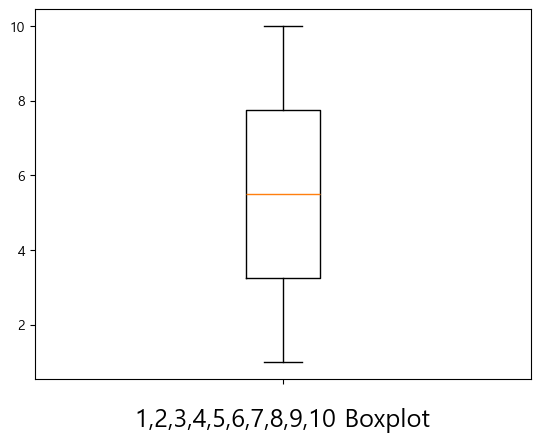

In [38]:
#이상치가 있는지 체크할 때 박스플롯을 사용함
#박스가 아래 쪽에 있으면 값이 작구나, 위에는 크구나 할 수 있음
plt.boxplot(sr)
plt.xticks(color='w')
plt.xlabel("1,2,3,4,5,6,7,8,9,10 Boxplot", fontsize=18)
plt.show()

In [39]:
sr.describe()

count    10.00000
mean      5.50000
std       3.02765
min       1.00000
25%       3.25000
50%       5.50000
75%       7.75000
max      10.00000
dtype: float64

In [40]:
sr[10] = 20

In [41]:
print(sr)

0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
9     10
10    20
dtype: int64


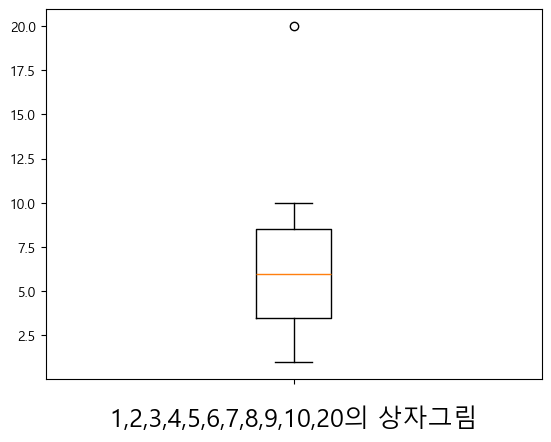

In [42]:
plt.boxplot(sr)
plt.xticks(color='w')
plt.xlabel("1,2,3,4,5,6,7,8,9,10,20의 상자그림", fontsize=18)
#20이라는 값을 이상치로 판단해서 원으로 표시, 그리고 평범한 값? 은 그대로 상자로 표현함
#원이 없다면 이상치가 없다는 의미 
plt.show()

In [43]:
sr.describe()

count    11.000000
mean      6.818182
std       5.231026
min       1.000000
25%       3.500000
50%       6.000000
75%       8.500000
max      20.000000
dtype: float64

In [44]:
def outliers(sr):
    Q1= sr.quantile(0.25)  # 1사분위 
    Q3 = sr.quantile(0.75) # 3사분위
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    return upper_limit, lower_limit

In [45]:
outliers(sr)

(np.float64(16.0), np.float64(-4.0))

### 이상치 판단 기준 : (Q1 – **1.5 * IQR**) 보다 작거나 (Q3 + **1.5 * IQR**) 보다 큰 데이터

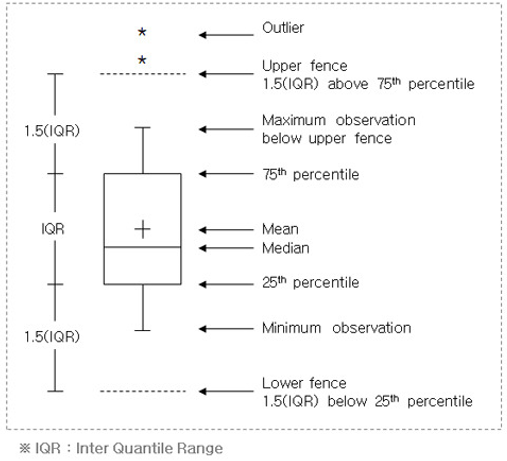

### 이상치 처리의 또 다른 예

### auto-mpg.csv 의 설명
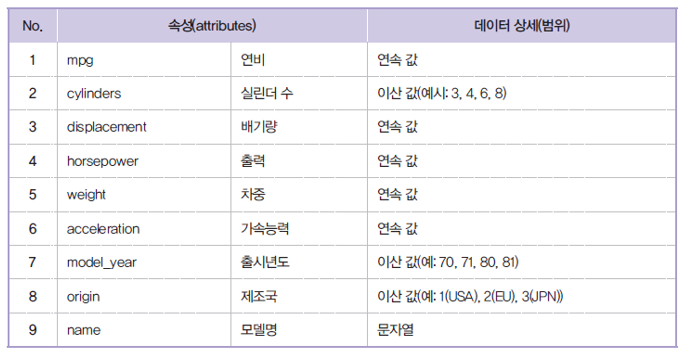

In [46]:
#이산값은 평균이 의미가 없는 것
#범주형 / 대소관계를 나눌 수 없을떄
#지역을 숫자로 나타낸거지, 크다 작다를 표현한게 아님. 이런 경우를 이산 값이라고 함
#연속값이라는 건 수치 데이터라는 의미, 큰 숫자는 큰 값을 의미
#auto-mpgg 헤더 없길래 직접
#shape을 사용해서 몇 행 몇 열인지 알 수 있음
import pandas as pd
df = pd.read_csv('./data/auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 
display(df.head(3))    

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite


In [47]:
df.shape

(398, 9)

In [48]:
print(df.dtypes)   

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model year        int64
origin            int64
name             object
dtype: object


In [49]:
# horsepower 열의 고유값 확인
print(df['horsepower'].unique())
#?가 있어서 문자열로 계산함
#하지만 수치데이터를 사용할때는 숫자로 함 

['130.0' '165.0' '150.0' '140.0' '198.0' '220.0' '215.0' '225.0' '190.0'
 '170.0' '160.0' '95.00' '97.00' '85.00' '88.00' '46.00' '87.00' '90.00'
 '113.0' '200.0' '210.0' '193.0' '?' '100.0' '105.0' '175.0' '153.0'
 '180.0' '110.0' '72.00' '86.00' '70.00' '76.00' '65.00' '69.00' '60.00'
 '80.00' '54.00' '208.0' '155.0' '112.0' '92.00' '145.0' '137.0' '158.0'
 '167.0' '94.00' '107.0' '230.0' '49.00' '75.00' '91.00' '122.0' '67.00'
 '83.00' '78.00' '52.00' '61.00' '93.00' '148.0' '129.0' '96.00' '71.00'
 '98.00' '115.0' '53.00' '81.00' '79.00' '120.0' '152.0' '102.0' '108.0'
 '68.00' '58.00' '149.0' '89.00' '63.00' '48.00' '66.00' '139.0' '103.0'
 '125.0' '133.0' '138.0' '135.0' '142.0' '77.00' '62.00' '132.0' '84.00'
 '64.00' '74.00' '116.0' '82.00']


### 이상치 삭제하고 타입 변환

In [50]:
df['horsepower'] = df['horsepower'].replace('?', None)     
# '?'로 했을 때 결측치 처리가 어려워서, None으로 함->  None(np.nan)으로 변경
df.dropna(subset=['horsepower'], axis=0, inplace=True)   # 누락데이터 행을 삭제
#?다 날리고 나머지 
df['horsepower'] = df['horsepower'].astype('float')      # 문자열을 실수형으로 변환
#데이터를 형변환해서 사용해주고 있음

# horsepower 열의 자료형 확인
print(df['horsepower'].dtypes)  

float64


In [51]:
print(df.dtypes) 

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model year        int64
origin            int64
name             object
dtype: object


## **데이터 전처리(3)**
### 중복 데이터의 채크와 처리

In [52]:
import pandas as pd

# 중복 데이터를 갖는 데이터프레임 만들기 C1,c2,c3 컬럼이 됨
df = pd.DataFrame({'c1':['a', 'a', 'b', 'a', 'b'],
                  'c2':[1, 1, 1, 2, 2],
                  'c3':[1, 1, 2, 2, 2]})
display(df)
#1,2행 중복됨

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [53]:
# 데이터프레임의 특정 열 데이터에서 중복값 찾기
df_dup = df.duplicated()#duplicated 중복된건지 확인 
#중복된 행이면 True 아니면 false근데 첫번째는 비교할 대상이 없으니 항상 false
print(df_dup)

0    False
1     True
2    False
3    False
4    False
dtype: bool


In [54]:
# 데이터프레임의 특정 열 데이터에서 중복값 찾기
col_dup = df['c2'].duplicated()
print(col_dup) #중복된 행이 3개나 됨

0    False
1     True
2     True
3    False
4     True
Name: c2, dtype: bool


In [55]:
# 데이터프레임에서 중복 행을 제거
df2 = df.drop_duplicates() #0이랑 같은 행인 1이 버려짐. 
display(df2)

,c1,c2,c3
0,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [56]:
# c2, c3열을 기준으로 중복 행을 제거
df3 = df.drop_duplicates(subset=['c2', 'c3']) 
#(subset=['c2', 'c3'])만 가지고 중복된 행을 제거하겠다는 의미 
display(df3) #1이랑 4에 해당하는 데이터가 사라진거 볼 수 있음

,c1,c2,c3
0,a,1,1
2,b,1,2
3,a,2,2


In [57]:
df3.reset_index(inplace=True)#인덱스를 다시 컬럼으로 바꾸기 
display(df3)

,index,c1,c2,c3
0,0,a,1,1
1,2,b,1,2
2,3,a,2,2


In [58]:
# 월별 지역별 매출 데이터
import numpy as np
import pandas as pd

np.random.seed(42)

months = ['1월','2월','3월'] * 12
regions = ['서울','부산','대전','광주'] * 9
sales_data = pd.DataFrame({
    '월': months,
    '지역': regions,
    '매출': np.random.randint(1000, 9000, 36),
    '수량': np.random.randint(10, 100, 36),
})
display(sales_data)

,월,지역,매출,수량
0,1월,서울,8270,98
1,2월,부산,8603,58
2,3월,대전,1860,68
3,1월,광주,6390,51
4,2월,서울,6226,69
5,3월,부산,6191,89
6,1월,대전,4772,24
7,2월,광주,4092,71
8,3월,서울,6734,71
9,1월,부산,7265,56


In [59]:
# pivot_table
pivot = pd.pivot_table(
    sales_data,
    values='매출',
    index='지역',
    columns='월',
    aggfunc='sum',
)#행마다 합계, 열마다 합계 
pivot

월,1월,2월,3월
지역,,,
광주,14267,7406,17121
대전,21023,8352,17040
부산,20126,23762,16161
서울,20307,16708,14974


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

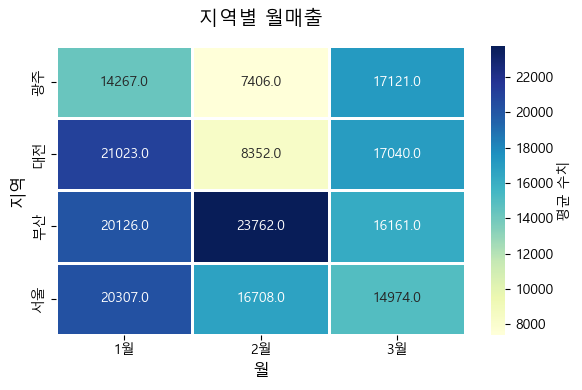

In [61]:
plt.figure(figsize=(6, 4))
sns.heatmap(# heatmap 데이터 분석 시각화 
    pivot,
    annot=True,  # 셀에 평균값 표시
    fmt=".1f",  # 소수점 첫째 자리 포맷
    cmap="YlGnBu",  # 값이 커질수록  노란색 -> 그린 -> 파란색
    linewidths=1,#선의 두께 
    cbar_kws={"label": "평균 수치"},  # 컬러바에 라벨 추가
)

plt.title("지역별 월매출", fontsize=14, pad=15)
plt.xlabel("월", fontsize=12)
plt.ylabel("지역", fontsize=12)
plt.tight_layout()  # 레이아웃 여백 최적화
plt.show()
#값이 적을 수록 노랑 크면 그린  

<hr style="background-color : green; height : 5px">

## **범주형 데이터 전처리**

- 범주형 데이터란 관측값이 숫자가 아닌 미리 정의된 여러 범주(그룹) 중 하나로 분류되는 데이터
- 성별, 혈액형, 만족도 조사 등이 이에 속하며, 사칙연산이나 평균을 구하는 것이 불가능
- 명목형(Nominal) - 성별(남/여), 혈액형(A, B, O, AB), 거주 지역(서울, 부산), 우편번호
- 순서형(Ordinal) - 학점(A+, A, B+), 설문조사 응답(매우 만족, 보통, 매우 불만족), 소설의 등급
- 평균 등은 의미없고 주로 빈도수를 계산해서 분석(도수분포표, 막대그래프, 파이차트)
- **머신러닝&딥러닝 API들은 문자열 값을 입력 값으로 처리 하지 않기 때문에 숫자 형으로 변환해야 함**
- 범주형 속성의 경우 전처리를 통해 정수값으로 변환(원-핫 인코딩, 레이블 인코딩)
- 범주형이 아닌 단순 문자열인 경우 일반적으로 제거

### 범주형 속성(피쳐)의 처리 방법
#### - 레이블 인코딩
#### - 더미화(원-핫 인코딩)

----

### 레이블 인코딩(Label encoding)
#### 문자열(범주형) 값을 0 부터 1씩 증가하는 값으로 변환(숫자형 카테고리)
#### 숫자의 차이가 모델에 영향을 주지 않는 트리 계열 모델(의사결정나무, 랜덤포레스트)에 적용 가능
#### 숫자의 차이가 모델에 영향을 미치는 선형 계열 모델(로지스틱회귀, SVM, 신경망)에는 사용하지 않음

### sklearn.preprocessing.LabelEncoder 사용
#### <span style="color:red">fit() : 어떻게 변환할 지 학습</span>
#### <span style="color:red">transform(): 문자열를 숫자로 변환</span>
#### <span style="color:red">fit_transform() : 학습과 변환을 한번에 처리 (fit + transform)</span>
#### inverse_transform() : 숫자를 문자열로 변환
#### classes_ : 인코딩한 클래스(레벨) 조회

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
foods = ['짜장면','짜장면','냉면','라면','라면','냉면', '짬뽕']
le = LabelEncoder()
le.fit(foods) 
label = le.transform(foods)
print(label)
print(type(label))

In [ ]:
print(le.classes_)
print(le.inverse_transform(label))

In [ ]:
import pandas as pd
df = pd.DataFrame({'item' : ['TV', '냉장고', '전자레인지', '컴퓨터', 'TV', '선풍기', '선풍기', '믹서', '믹서']})
df

In [ ]:
le.fit(df.item) 
label = le.transform(df.item)
print(label)

In [ ]:
df2 = df.copy()

In [ ]:
df2.item = label
df2

---
### **더미화 - 원핫 인코딩(One-Hot encoding)**
#### N개의 클래스를 N 차원의 One-Hot 벡터로 표현되도록 변환
#### 고유값들을 피처로 만들고 정답에 해당하는 열은 1로 나머진 0으로 표시
#### 변환해야 하는 값의 종류가 여러 개일 때
#### 숫자의 차이가 모델에 영향을 미치는 선형 계열 모델(로지스틱회귀, SVM, 신경망)에서 범주형 데이터 변환시 라벨 인코딩 보다 원핫 인코딩을 사용

----
### [판다스]
#### <span style="color:red">pandas.get_dummies(DataFrame [, columns=[변환할 컬럼명]])</span> 함수 이용
#### DataFrame에서 범주형(문자열) 변수만 변환
----
### [사이킷런]
#### <span style="color:red">sklearn.preprocessing.OneHotEncoder</span> 이용
#### fit(): 어떻게 변환할 지 학습
#### transform(): 문자열를 숫자로 변환
#### fit_transform(): 학습과 변환을 한번에 처리
#### get_feature_names_out() : 원핫인코딩으로 변환된 컬럼의 이름을 반환
#### DataFrame을 넣을 경우 모든 변수들을 변환하므로 범주형 컬럼만 처리하도록 해야 함
----

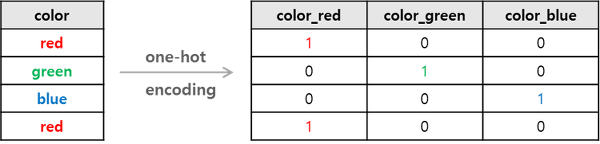

### **pandas의 get_dummies 기능을 활용한 인코딩**

In [ ]:
import pandas as pd
df = pd.DataFrame({'item' : ['TV', '냉장고', '전자레인지', '컴퓨터', 'TV', '선풍기', '선풍기', '믹서', '믹서']})
df

In [ ]:
pd.get_dummies(df)

In [ ]:
pd.get_dummies(df, prefix="my")

In [ ]:
pd.get_dummies(df, prefix="", prefix_sep="")

In [ ]:
fruit = pd.DataFrame({'name':['apple', 'banana', 'cherry', 'durian', None],
                      'color':['red', 'yellow', 'red', 'green', None]})
fruit

In [ ]:
pd.get_dummies(fruit)

In [ ]:
pd.get_dummies(fruit, columns = ['name'])

In [ ]:
pd.get_dummies(fruit['name'])

In [ ]:
pd.get_dummies(fruit['name'], dummy_na = True)

### 사이킷런에서 지원하는 원핫인코딩 구현
---

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
df = pd.DataFrame({'item' : ['TV', '냉장고', '전자레인지', '컴퓨터', 'TV', '선풍기', '선풍기', '믹서', '믹서']})
df

In [ ]:
df['item']

In [ ]:
encoder = OneHotEncoder(dtype='int64')
onehot = pd.DataFrame(encoder.fit_transform(df[['item']]).toarray(), columns = encoder.get_feature_names_out())
df = pd.concat([df,onehot], axis = 1) 
df

In [ ]:
df.drop(columns = ['item'])

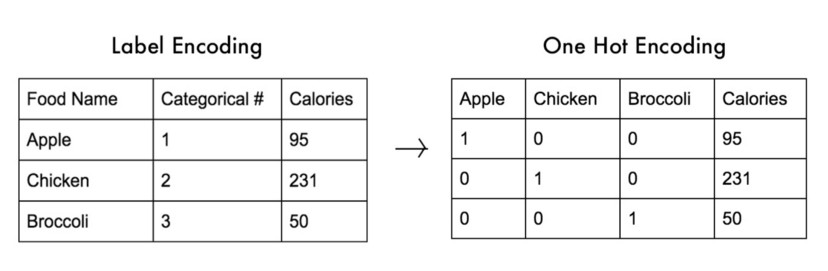

<hr style="background-color : green; height : 5px">

### **수치형 데이터 전처리**
각 열(변수, 피처, 속성)이 가지는 값들의 **숫자 범위(Scale)** 가 다를 경우 이 값의 범위를 일정한 범위로 맞추는 작업

### **스케일링**

#### 데이터 분석 또는 AI 프로그래밍을 수행하면서 많이 겪는 문제중 하나가 <span style="color:red">데이터 단위의 불일치</span>임
#### 칼럼간에 데이터의 단위가 다르면 칼럼마다 스케일이 크게 차이가 나게 되고 결과에 영향을 주게 됨
#### 데이터 스케일링 작업을 통해, 모든 특성의 범위를 동일하게 만들어줘야 함
#### **데이터의 컬럼별로 단위 또는 범위를 통일시켜 주는 작업**

***
### scikit-learn의 scaler를 사용하기 이전에 주의 해야할 점
- scaler는 fit과 transform 메서드를 지원한다.
- fit 메서드로 데이터의 분포를 추정하고, transform 메서드로 실제 데이터의 스케일을 조정한다.
- **fit 메서드는 훈련 데이터에만 적용하고 이후에 transform 메서드를 훈련 데이터와 테스트 데이터 모두에 적용**한다.
- scaler는 fit_transform()이란 단축 메서드를 제공한다.
- 훈련 데이터에는 fit_transform()메서드를 적용하고, 테스트 데이터에는 transform()메서드를 적용한다.
- 일반적으로 타겟(y) 데이터에 대한 스케일링은 진행하지 않는다.

---
### **[ Min-Max 스케일링(정규화) ]**
#### 데이터의 상대적 크기에 대한 영향을 줄이기 위해 데이터범위를 0~1로 변환 - MinMax스케일러라고도 함
#### 2개 이상의 대상 컬럼(변수, 피쳐, 속성)의 단위가 다를 때 대상 데이터를 같은 기준으로 볼 수 있게 함
#### 데이터가 평균으로부터 얼마나 떨어져있는지 나타내는 값으로, 특정 범위를 벗어난 데이터는 outlier로 간주, 제거 
### 식 : <span style="color:red">(측정값 - 최소값) / (최대값 - 최소값)</span>
### sklearn.preprocessing 의 MinMaxScaler 사용

---
### **[ Z-score 스케일링(표준화) ]** 
#### 피쳐의 값들이 평균이 0이고 표준편차가 1인 범위(표준정규분포)에 있도록 변환
#### 데이터가 평균으로부터 얼마나 떨어져있는지 나타내는 값으로, 특정 범위를 벗어난 데이터는 outlier로 간주, 제거 
#### 데이터를 0을 중심으로 양쪽으로 데이터를 분포시키는 방법
####  Z-score 스케일링을 하면 각 데이터들이 평균을 기준으로 얼마나 떨어져 있는지를 나타내는 값으로 변환됨
### 식(Z-score 표준화) : <span style="color:red">(측정값 - 평균) / 표준편차</span>
### sklearn.preprocessing 의 StandardScaler 사용
---

### Min-Max 스케일링(정규화) 

In [ ]:
from sklearn.preprocessing import MinMaxScaler
a = [[10], [9], [8], [6], [2]]
print(a)
print(type(a))
print('-------- MinMaxScaling ---------')
scaler = MinMaxScaler(feature_range=(0,1))
a = scaler.fit_transform(a)
print(a)
print(type(a))

### Z-score 스케일링(표준화)

In [ ]:
from sklearn.preprocessing import StandardScaler
a = [[10], [9], [8], [6], [2]]
print(a)
scaler = StandardScaler()
print('-------- StandardScaling ---------')
a = scaler.fit_transform(a)
print(a)
print('--------------------------------')
print('평균 : ', a.mean())
print('표준편차 : ', a.std())

### 피쳐스케일링이란 서로 다른 범위(scale)를 가질 때 이를 동일한 스케일로 맞추는 작업 

### **표준화(StandardScaler)**
데이터의 피처 각각이 평균이 0, 분산이 1인 가우시안 정규 분포를 가진 값으로 변환하는 행위이다. 표준화는 정규화(MinMaxScaler)에 비해 이상치에 상대적으로 '덜' 민감하다. 평균과 표준편차를 사용하기 때문에 데이터가 완전히 정해진 범위(0~1) 내로 구겨지지 않고 원래의 분포 형태를 유지하므로 아주 크거나 작은 이상치가 있어도 다른 데이터들이 한곳으로 과도하게 뭉치지 않다.

### **정규화(MinMaxScaler)**
각각의 피처가 정확하게 0과 1 사이에 위치하도록 변환됩니다. 따라서 최솟값은 0, 최댓값은 1이 되며, 그 사이의 값들을 선형적으로 비례하게 스케일링된다. 정규화는 이상치에 극도로 민감하다.최솟값($x_{min}$)과 최댓값($x_{max}$)을 기준으로 삼기 때문에, 만약 데이터에 뜬금없이 엄청나게 큰 이상치(예: 다른 값들은 다 1~10인데 혼자 1,000,000인 값)가 하나라도 포함되어 있다면, 나머지 일반적인 데이터들은 전부 0에 아주 가깝게 뭉쳐버리게 된다. 이로 인해 변별력이 크게 떨어진다.

- 데이터가 정규분포를 따르거나, 이상치가 존재할 때는 표준화(StandardScaler)
- 데이터의 분포를 모르거나, 이상치가 없다는 확신이 있을 때는 정규(MinMaxScaler)

---

## 데이터 전처리의 필요성을 예제를 통해 확인하기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

game_usage = pd.read_csv('data/game_usage.csv')
game_usage.head(3)

In [ ]:
game_usage

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')  

In [ ]:
X = game_usage['time spent']
Y = game_usage['game level']

plt.title("게임 플레이어 데이터", size=20)
plt.xlabel('게임 시간')
plt.ylabel('게임 레벨') 
plt.scatter(X, Y)
plt.show()

In [ ]:
from sklearn import cluster
import numpy as np

def kmeans_predict_plot(data, k):
    model = cluster.KMeans(n_clusters=k)
    model.fit(data)
    labels = model.predict(data)
    colors = np.array(['red', 'green', 'blue', 'magenta']) 
    plt.suptitle('k-Means clustering, k={}'.format(k)) 
    plt.scatter(data[:, 0], data[:, 1], color=colors[labels])

gamer_data = np.column_stack((X, Y))
kmeans_predict_plot(gamer_data, k = 4)
plt.title("게이 플레이어 데이터", size=20)
plt.xlabel('게임 시간')
plt.ylabel('게임 레벨') 

In [ ]:
kmeans_predict_plot(gamer_data, k = 4)
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.title("게임 플레이어 데이터", size=20)
plt.xlabel('게임 시간')
plt.ylabel('게임 레벨') 

### 데이터 정규화 방법을 이용하자

In [ ]:
# Min-Max 스케일러
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(gamer_data)
n_data = scaler.transform(gamer_data)

In [ ]:
n_data[:, 0].mean(), n_data[:, 1].mean()

In [ ]:
n_data[:, 0].min(), n_data[:, 0].max()

In [ ]:
n_data[:, 1].min(), n_data[:, 1].max()

In [ ]:
kmeans_predict_plot(n_data, k = 4) # 4개의 군집 생성
plt.title("게임 플레이어 데이터", size=20)
plt.xlabel('게임 시간')
plt.ylabel('게임 레벨') 

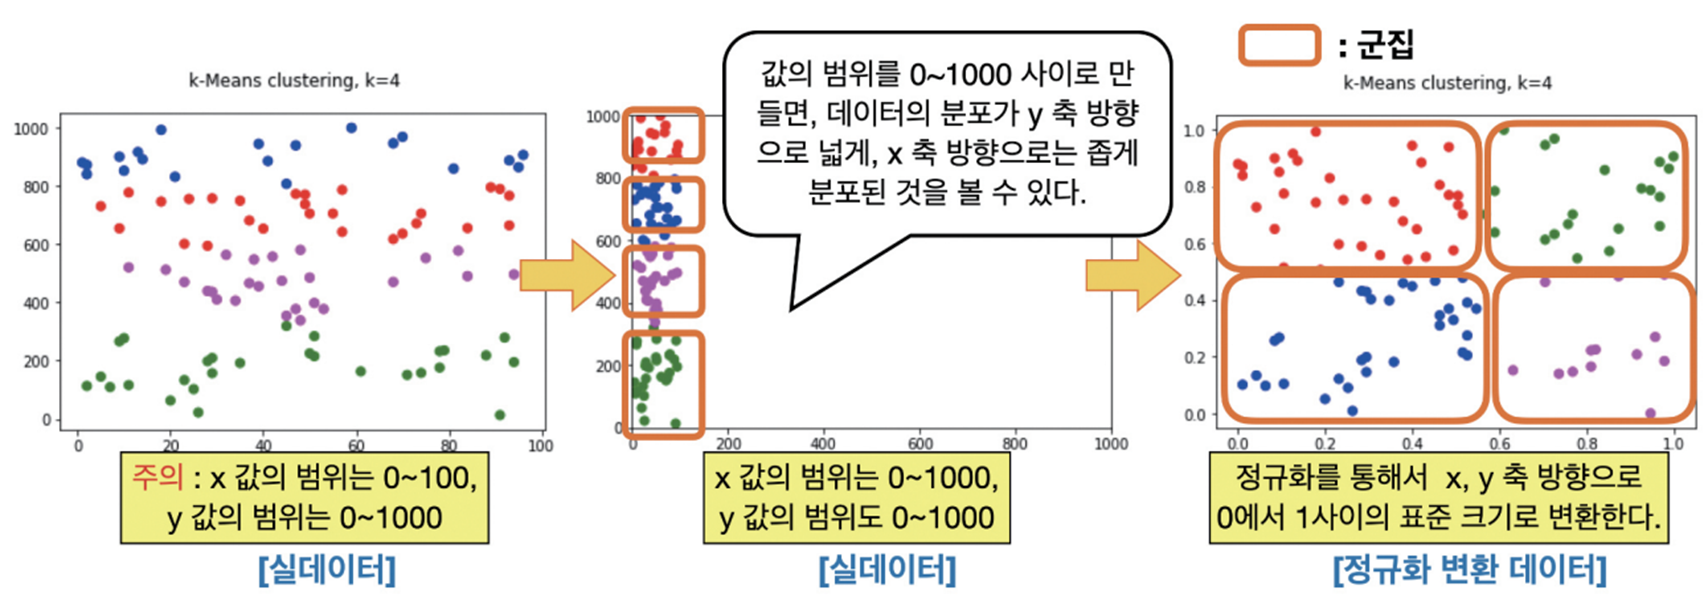

- 범위가 다른 데이터 특성 끼리는 상대적인 비교를 하기 어렵다. 
- 머신러닝 알고리즘은 입력 숫자 특성들의 범위가 많이 다르면 잘 작동하지 않을 수 있다.
- 데이터의 변화폭이 클 수록 머신러닝은 특성의 중요도를 과대평가 할 수 있다.

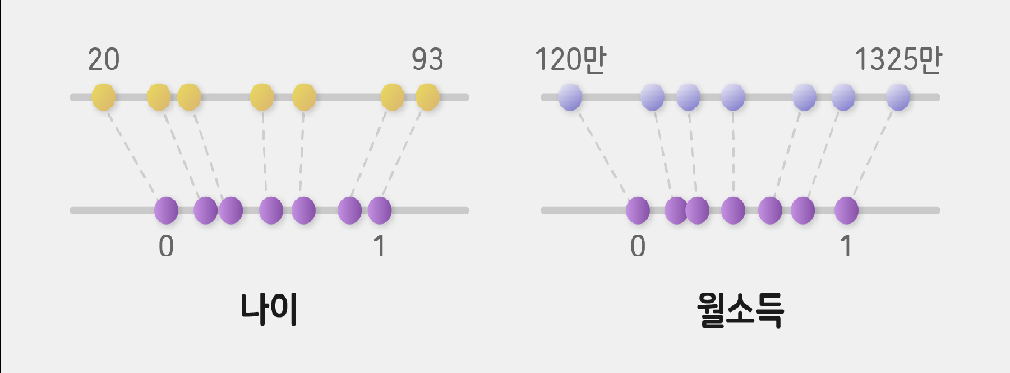

---

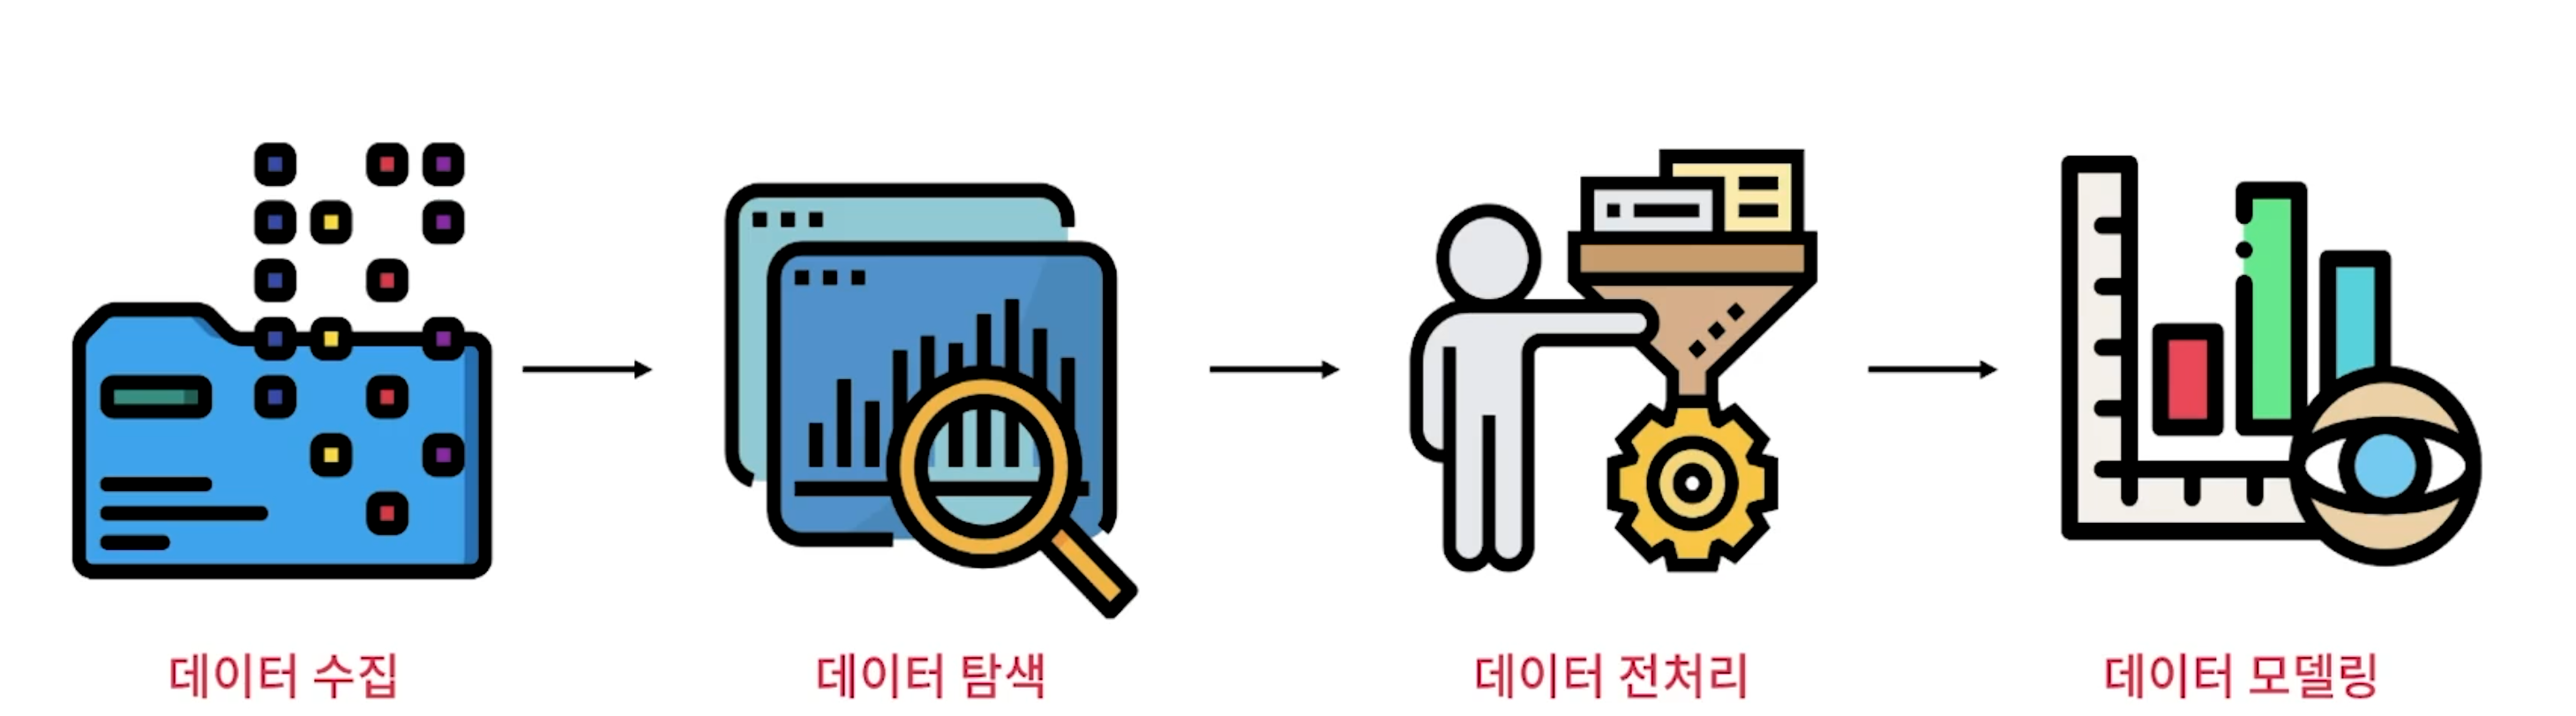